# Configuración y librerías

In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import glob
import os
from scipy.signal import butter, filtfilt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Configuración de figuras
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Visualización del Espectrograma (Antes del LDA)

**Usamos plt.specgram() para visualizar el espectrograma de tanto los motores sanos como los averiados.**

In [ ]:
def plot_comparativa(path_sano, path_averiado):
    plt.figure(figsize=(15, 5))

    # Motor Sano
    plt.subplot(1, 2, 1)
    y_s, sr_s = librosa.load(path_sano, sr=None)
    plt.specgram(y_s, Fs=sr_s, NFFT=1024, noverlap=512)
    plt.title("Espectrograma: Motor SANO")
    plt.colorbar(label="dB")

    # Motor Averiado
    plt.subplot(1, 2, 2)
    y_a, sr_a = librosa.load(path_averiado, sr=None)
    plt.specgram(y_a, Fs=sr_a, NFFT=1024, noverlap=512)
    plt.title("Espectrograma: Motor AVERIADO")
    plt.colorbar(label="dB")
    plt.show()

Generando comparativa visual...


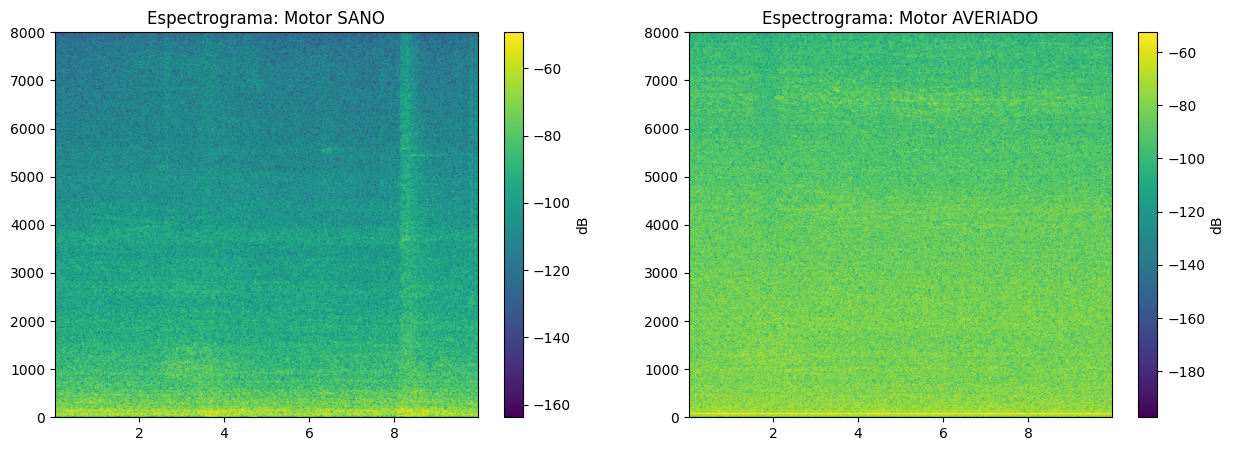

In [ ]:
# Definimos las rutas a dos archivos de ejemplo del ID 00
path_ejemplo_sano = '/content/drive/MyDrive/Proyecto_PSIV/data/fan/id_00/normal/00000004.wav'
path_ejemplo_averiado = '/content/drive/MyDrive/Proyecto_PSIV/data/fan/id_00/abnormal/00000004.wav'

print("Generando comparativa visual...")
plot_comparativa(path_ejemplo_sano, path_ejemplo_averiado)

# Análisis de la Comparativa Visual (Espectrogramas)
### Al observar la comparativa entre el motor sano y el averiado, podemos extraer las siguientes conclusiones técnicas:

- **Presencia de Armónicos de Baja Frecuencia**: Las líneas brillantes de la parte baja (entre 0 y 2000 Hz) en el Averiado no son tan nítidas. Esto indica que el motor no gira de forma tan estable; hay pérdidas de energía porque algo está rozando o vibrando fuera de su eje.

- **Definición en Altas Frecuencias**: En el motor sano observamos una textura uniforme y definida en todas las frecuencias, mientras que en el averiado hay borrones de verde oscuro irregulares, lo que indica que el sonido no es tan límpio y tiene irregularidades.

- **Similitud General (Justificación del Proyecto)**: En la comparativa visual, observamos que el Motor Sano presenta unos armónicos fundamentales muy bien definidos y estables en el tiempo (líneas horizontales nítidas). Por el contrario, el Motor Averiado muestra una degradación de estos armónicos, que aparecen más difusos. Esto nos hace ver que la averia no produce un ruido exagerado que facilite su detección, sino que se manifiesta como una alteración de la estabilidad cíclica del ventilador, validando la necesidad de usar 40 coeficientes MFCC para capturar estas variaciones tan finas en la textura del sonido.

# Extracción de características

**Extracción de Descriptores: Pasamos un audio bruto (miles de muestras) a 13 valores clave (MFCC) que representan el "timbre" del motor.**

In [ ]:
from scipy.signal import butter, filtfilt

def butter_highpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    y = filtfilt(b, a, data)
    return y

# En la función extract_features, antes de los MFCC:
# y = butter_highpass_filter(y, cutoff=100, fs=sr)

def extract_features(audio_path, n_mfcc=40):
    """
    Carga un audio y extrae su 'huella dactilar' (MFCCs).
    Calculamos la media de los coeficientes a lo largo del tiempo
    para tener un vector de tamaño fijo.
    """
    # sr=None mantiene la frecuencia de muestreo original del dataset (16kHz)
    y, sr = librosa.load(audio_path, sr=None)

    # Aplicamos el filtro
    y = butter_highpass_filter(y, cutoff=100, fs=sr)

    # Extraemos los MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # Promediamos en el eje del tiempo (axis=1) para tener 13 valores por audio
    mfccs_processed = np.mean(mfccs, axis=1)

    return mfccs_processed

# Carga del Dataset (Data Loop)

In [ ]:
base_path = '/content/drive/MyDrive/Proyecto_PSIV/data/fan/'
# Definimos las etiquetas para la leyenda de las gráficas
categories = ['Sano', 'Fallo_ID00', 'Fallo_ID02', 'Fallo_ID06']

X = [] # Vectores MFCC
y = [] # Etiquetas

# Cargamos audios SANOS (Mezclamos un poco de cada ID para la clase 'Sano')
ids_disponibles = ['id_00', 'id_02', 'id_06']

for m_id in ids_disponibles:
    path = os.path.join(base_path, m_id, 'normal', "*.wav")
    files = glob.glob(path)
    # Cogemos un poco más de cada uno (65) para seguir teniendo unos 200 sanos aprox.
    for f in files[:65]:
        X.append(extract_features(f))
        y.append(0)

# Cargamos audios anormales
for idx, m_id in enumerate(ids_disponibles):
    path = os.path.join(base_path, m_id, 'abnormal', "*.wav")
    files = glob.glob(path)
    print(f"Cargando {len(files)} fallos de la máquina {m_id}...")
    for f in files[:150]:
        X.append(extract_features(f))
        y.append(idx + 1) # Las etiquetas serán 1, 2 y 3

X = np.array(X)
y = np.array(y)

print(f"\nDataset reconfigurado: {len(X)} muestras totales con {len(categories)} clases.")

Cargando 407 fallos de la máquina id_00...
Cargando 359 fallos de la máquina id_02...
Cargando 361 fallos de la máquina id_06...

Dataset reconfigurado: 645 muestras totales con 4 clases.


# Reducción de dimensionalidad con LDA

**El LDA usa los 13 valores para quedarse solo con los 2 ejes que más diferencian a un motor sano de uno roto.**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Dividir dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40, stratify=y)

# Estandarizar (Media 0, Varianza 1)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test) # Muy importante --> transform()

# Entrenar LDA con los datos escalados
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

print(f"LDA completado. Proyectadas {X_train.shape[1]} dimensiones a 2D.")

LDA completado. Proyectadas 40 dimensiones a 2D.


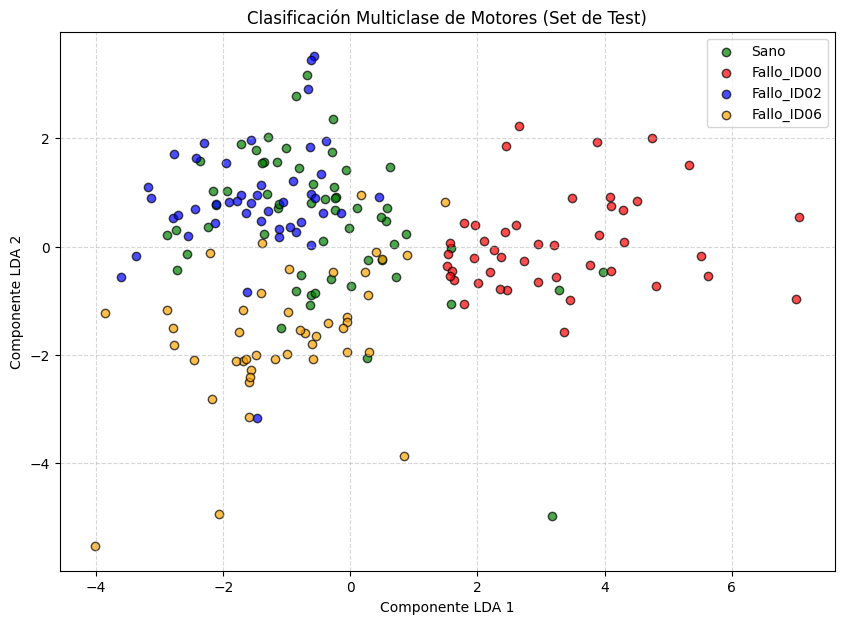

In [ ]:
def plot_lda(X_projected, y_labels, title):
    plt.figure(figsize=(10, 7))

    # Definimos 4 colores para nuestras 4 clases actuales
    # Verde = Sano, Rojo = ID00, Azul = ID02, Naranja = ID06
    colors = ['g', 'r', 'b', 'orange']

    for i, color, label in zip(range(len(categories)), colors, categories):
        plt.scatter(X_projected[y_labels == i, 0],
                    X_projected[y_labels == i, 1],
                    c=color, label=label, alpha=0.7, edgecolors='k')

    plt.title(title)
    plt.xlabel('Componente LDA 1')
    plt.ylabel('Componente LDA 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Visualizamos el set de test
plot_lda(X_test_lda, y_test, "Clasificación Multiclase de Motores (Set de Test)")

# Analisis con MLP

****

In [ ]:
from sklearn.neural_network import MLPClassifier

# Creamos el modelo MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# Entrenamos el modelo
mlp.fit(X_train, y_train)

# Predicción
y_pred_mlp = mlp.predict(X_test)

# Obtenemos las probabilidades de salida
X_test_mlp = mlp.predict_proba(X_test)

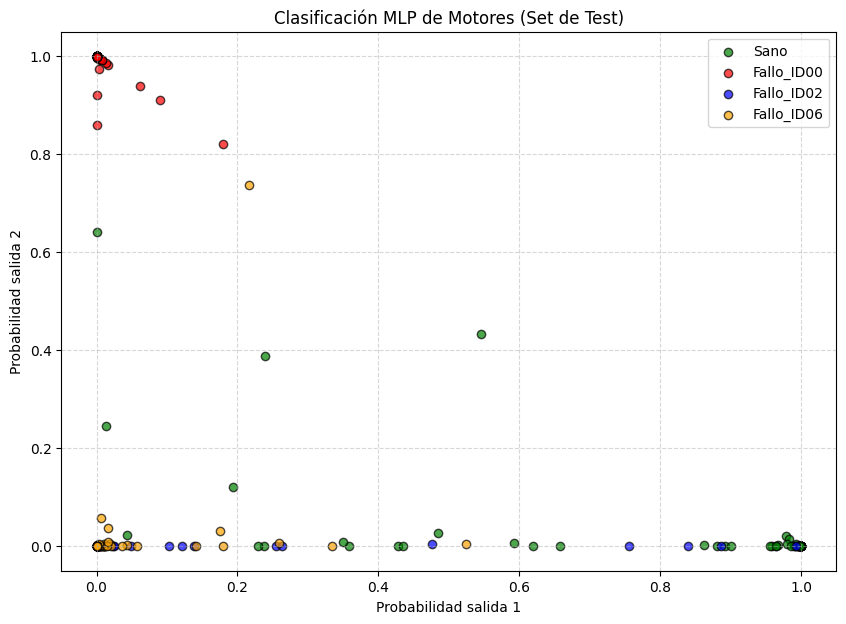

In [ ]:
def plot_MLP(X_projected, y_labels, title):
    plt.figure(figsize=(10, 7))

    # Definimos 4 colores para nuestras 4 clases actuales
    # Verde = Sano, Rojo = ID00, Azul = ID02, Naranja = ID06
    colors = ['g', 'r', 'b', 'orange']

    for i, color, label in zip(range(len(categories)), colors, categories):
        plt.scatter(
            X_projected[y_labels == i, 0],
            X_projected[y_labels == i, 1],
            c=color,
            label=label,
            alpha=0.7,
            edgecolors='k'
        )

    plt.title(title)
    plt.xlabel('Probabilidad salida 1')
    plt.ylabel('Probabilidad salida 2')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

plot_MLP(
    X_test_mlp,
    y_test,
    "Clasificación MLP de Motores (Set de Test)"
)

# Matriz de confusión para evaluar los resultados

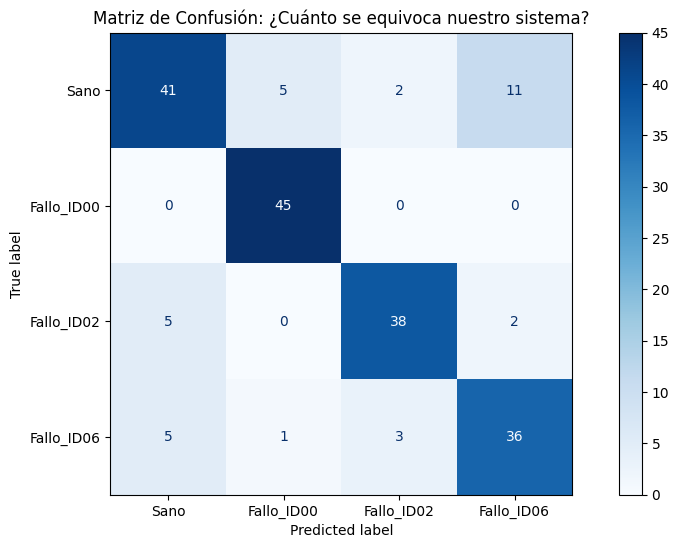

Accuracy LDA: 0.8247422680412371


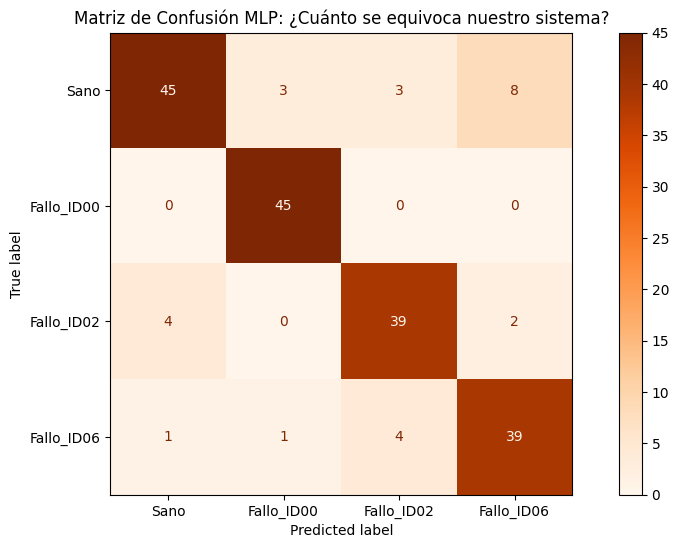

Accurancy MLP: 0.865979381443299


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# MATRIZ DE CONFUSIÓN LDA

y_pred = lda.predict(X_test) # El LDA no solo proyecta, también clasifica
cm = confusion_matrix(y_test, y_pred)
acc_lda = accuracy_score(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión: ¿Cuánto se equivoca nuestro sistema?")
plt.show()
print(f"Accuracy LDA: {acc_lda}")


# MATRIZ DE CONFUSIÓN MLP
y_pred_mlp = mlp.predict(X_test)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

disp_mlp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=categories
)

disp_mlp.plot(cmap=plt.cm.Oranges)
plt.title("Matriz de Confusión MLP: ¿Cuánto se equivoca nuestro sistema?")
plt.show()
print(f"Accurancy MLP: {acc_mlp}")


# Clasificador Binario: ¿Sano o Averiado?

Además de la clasificación multiclase con LDA, añadimos un bloque de **clasificación binaria** que responde únicamente a la pregunta: **¿el motor está sano o tiene algún fallo?**

Comparamos tres clasificadores:
- **Regresión Logística** (modelo lineal, interpretable)
- **SVM con kernel RBF** (margen máximo, robusto con alta dimensionalidad)
- **Random Forest** (ensamble de árboles, captura no-linealidades)

Evaluamos con **Accuracy**, **F1-score**, **AUC-ROC** y mostramos la curva ROC.

In [ ]:
# ── Clasificación Binaria: Sano (0) vs. Averiado (1) ──────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             roc_curve, classification_report,
                             ConfusionMatrixDisplay, confusion_matrix)
import matplotlib.pyplot as plt
import numpy as np

# Convertimos las etiquetas multiclase a binario: 0 = sano, 1 = averiado
y_bin_train = (y_train > 0).astype(int)
y_bin_test  = (y_test  > 0).astype(int)

print(f"Train  → sanos: {(y_bin_train==0).sum()}  |  averiados: {(y_bin_train==1).sum()}")
print(f"Test   → sanos: {(y_bin_test ==0).sum()}  |  averiados: {(y_bin_test ==1).sum()}")


Train  → sanos: 136  |  averiados: 315
Test   → sanos: 59  |  averiados: 135


In [ ]:
# ── Entrenamiento de los tres clasificadores ───────────────────────────────────
clf_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_svm = SVC(kernel='rbf', probability=True, random_state=42)
clf_rf  = RandomForestClassifier(n_estimators=200, random_state=42)

for name, clf in [('Logistic Regression', clf_lr),
                   ('SVM (RBF)',           clf_svm),
                   ('Random Forest',       clf_rf)]:
    clf.fit(X_train, y_bin_train)
    y_pred_bin = clf.predict(X_test)
    y_prob_bin = clf.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_bin_test, y_pred_bin)
    f1   = f1_score(y_bin_test, y_pred_bin)
    auc  = roc_auc_score(y_bin_test, y_prob_bin)
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  Accuracy : {acc:.3f}")
    print(f"  F1-score : {f1:.3f}")
    print(f"  AUC-ROC  : {auc:.3f}")
    print(classification_report(y_bin_test, y_pred_bin,
                                target_names=['Sano', 'Averiado']))



─────────────────────────────────────────────
  Logistic Regression
─────────────────────────────────────────────
  Accuracy : 0.794
  F1-score : 0.860
  AUC-ROC  : 0.859
              precision    recall  f1-score   support

        Sano       0.72      0.53      0.61        59
    Averiado       0.81      0.91      0.86       135

    accuracy                           0.79       194
   macro avg       0.77      0.72      0.73       194
weighted avg       0.79      0.79      0.78       194


─────────────────────────────────────────────
  SVM (RBF)
─────────────────────────────────────────────
  Accuracy : 0.835
  F1-score : 0.891
  AUC-ROC  : 0.888
              precision    recall  f1-score   support

        Sano       0.89      0.53      0.66        59
    Averiado       0.82      0.97      0.89       135

    accuracy                           0.84       194
   macro avg       0.85      0.75      0.78       194
weighted avg       0.84      0.84      0.82       194


───────────

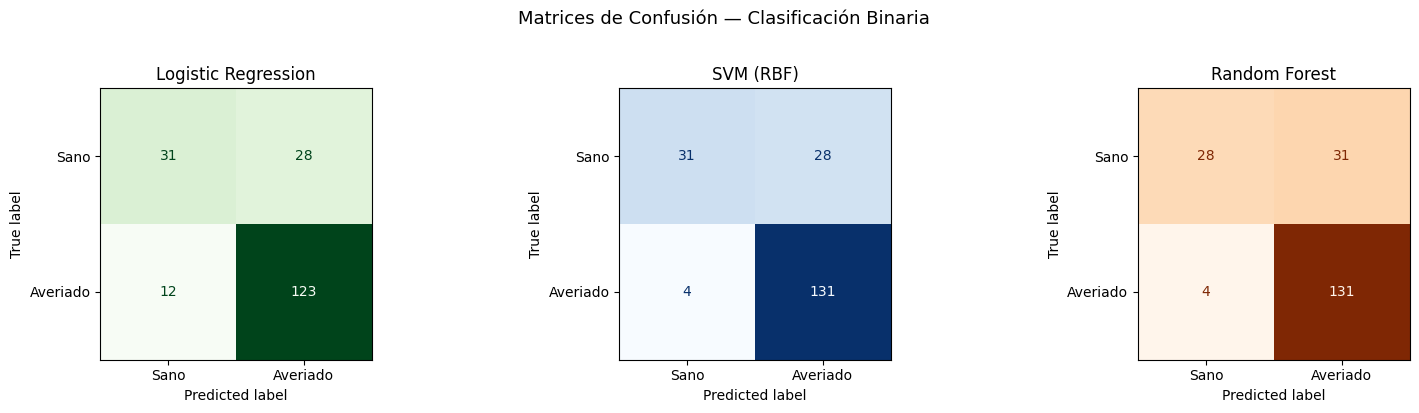

In [ ]:
# ── Matrices de confusión binarias (lado a lado) ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cmaps = [plt.cm.Greens, plt.cm.Blues, plt.cm.Oranges]

for ax, (name, clf), cmap in zip(
        axes,
        [('Logistic Regression', clf_lr), ('SVM (RBF)', clf_svm), ('Random Forest', clf_rf)],
        cmaps):
    y_pred_bin = clf.predict(X_test)
    cm_b = confusion_matrix(y_bin_test, y_pred_bin)
    ConfusionMatrixDisplay(cm_b, display_labels=['Sano', 'Averiado']).plot(
        ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(name)

plt.suptitle('Matrices de Confusión — Clasificación Binaria', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


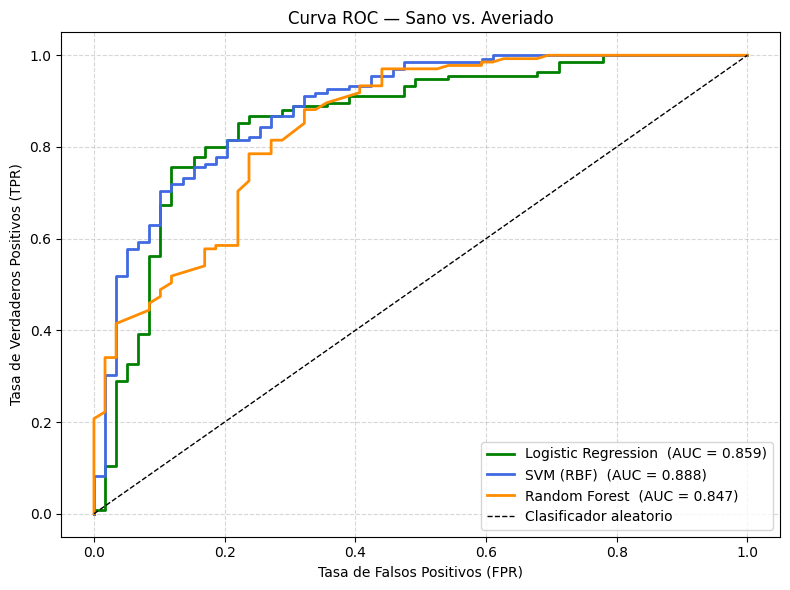

In [ ]:
# ── Curva ROC comparativa ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

colors_roc = ['green', 'royalblue', 'darkorange']
for (name, clf), color in zip(
        [('Logistic Regression', clf_lr), ('SVM (RBF)', clf_svm), ('Random Forest', clf_rf)],
        colors_roc):
    y_prob_bin = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_bin_test, y_prob_bin)
    auc = roc_auc_score(y_bin_test, y_prob_bin)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC — Sano vs. Averiado')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

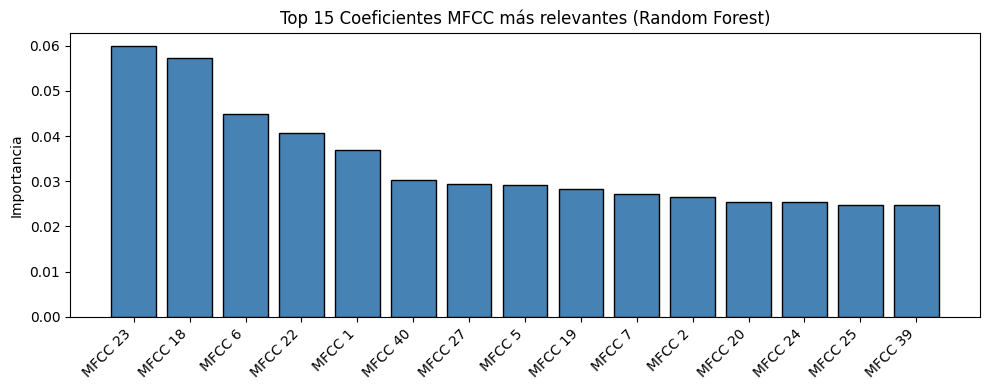

In [ ]:
# ── Importancia de características (Random Forest) ────────────────────────────
importances = clf_rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 MFCCs

plt.figure(figsize=(10, 4))
plt.bar(range(15), importances[indices], color='steelblue', edgecolor='k')
plt.xticks(range(15), [f'MFCC {i+1}' for i in indices], rotation=45, ha='right')
plt.ylabel('Importancia')
plt.title('Top 15 Coeficientes MFCC más relevantes (Random Forest)')
plt.tight_layout()
plt.show()
